In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, LeaveOneOut
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import f1_score, confusion_matrix, classification_report, accuracy_score, roc_auc_score, roc_curve, auc
from sklearn.model_selection import learning_curve, LeaveOneOut, GridSearchCV, cross_val_score
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.pipeline import make_pipeline
from sklearn.feature_selection import SelectKBest, f_classif, RFE, RFECV, SelectFromModel, SelectFpr, VarianceThreshold, chi2
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import FunctionTransformer
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC, LinearSVC
from sklearn.neighbors import KNeighborsClassifier

# Load, preprocessing

In [2]:
dataset = "C:/Users/tamer/Documents/PhD/ML/enhanced_metabolome.xlsx"
df = pd.read_excel(dataset, sheet_name = 'Paul_50%')
df_val = pd.read_excel(dataset, sheet_name = 'Saqib_50%')


#df = pd.read_excel(dataset, sheet_name = 'Paul')
#df_val = pd.read_excel(dataset, sheet_name = 'Saqib')

#df = pd.read_excel(dataset_total_path)
#df_val = pd.read_excel(dataset_val_path)

print(df.shape)
print(df_val.shape)

(24, 648)
(12, 648)


In [3]:
Class_A = 'LN'
Class_B = 'SN'

df = df[(df["Class"] == Class_A) | (df["Class"] == Class_B)]
df_val = df_val[(df_val["Class"] == Class_A) | (df_val["Class"] == Class_B)]

In [4]:
def encodage(df):
    code = {
    Class_A : 0,
    Class_B : 1
}
# Appliquer ce dictionnaire aux colonnes du dataset, avec la fonction map
    for col in df.select_dtypes('object'):
        df[col] = df[col].map(code)

    return df


def preprocessing(df):
    df = encodage(df)

    X = df.drop(['Class'], axis = 1)
    y = df['Class']

    # compter le nombre d'échantillons restants dans le dataset après avoir été inputé
    print(y.value_counts())

    return X, y

In [5]:
def old_encodage(df):
    code = {
    'LP' : 1,
    'SP' : 0,
    'LN' : 3,
    'SN' : 1
}
# Appliquer ce dictionnaire aux colonnes du dataset, avec la fonction map
    for col in df.select_dtypes('object'):
        df[col] = df[col].map(code)

    return df


def preprocessing(df):
    df = encodage(df)

    X = df.drop(['Class'], axis = 1)
    y = df['Class']

    # compter le nombre d'échantillons restants dans le dataset après avoir été inputé
    print(y.value_counts())

    return X, y

In [6]:
X_total, y_total = preprocessing(df)
X_val, y_val = preprocessing(df_val)

Class
0    6
1    6
Name: count, dtype: int64
Class
0    3
1    3
Name: count, dtype: int64


In [7]:
print("var before log2 transormation : " , X_total.var(axis=0).mean())
log2_transformer = FunctionTransformer(lambda x: np.log2(x + 1))
X_total = log2_transformer.fit_transform(X_total)
X_val = log2_transformer.fit_transform(X_val)
print("var after log2 transormation : " , X_total.var(axis=0).mean())

var before log2 transormation :  6.378347255133588e+17
var after log2 transormation :  6.050716535554722


In [8]:
def evaluation(model):
    model.fit(X_total, y_total)
    ypred = model.predict(X_val)
    print(confusion_matrix(y_val, ypred))
    print(classification_report(y_val, ypred))

# Définition modèle

In [9]:
vars_ = X_total.var(axis=0)
q = np.quantile(vars_, 0.5) 
selector = VarianceThreshold(threshold = q)

preprocessor = make_pipeline(selector)

LR_L1 = make_pipeline(preprocessor, StandardScaler(), LogisticRegression(penalty='l1', C=10, random_state = 0, solver = 'liblinear'))
#LR_L1 = make_pipeline(StandardScaler(), LogisticRegression(penalty='l1', C=10, random_state = 0, solver = 'liblinear'))
evaluation(LR_L1)

[[3 0]
 [3 0]]
              precision    recall  f1-score   support

           0       0.50      1.00      0.67         3
           1       0.00      0.00      0.00         3

    accuracy                           0.50         6
   macro avg       0.25      0.50      0.33         6
weighted avg       0.25      0.50      0.33         6



C:\Users\tamer\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\tamer\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\tamer\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [10]:
#hyper_params = {'logisticregression__C': [0.1, 1, 10], 'pipeline__variancethreshold__threshold' : np.arange(0.01, 0.99, 0.01)}
#grid = GridSearchCV(LR_L1, cv = LeaveOneOut(), param_grid=hyper_params, scoring='accuracy')
#grid.fit(X_total, y_total)
#print(grid.best_params_)
#evaluation(grid.best_estimator_)

# Outputs

## ROC curve

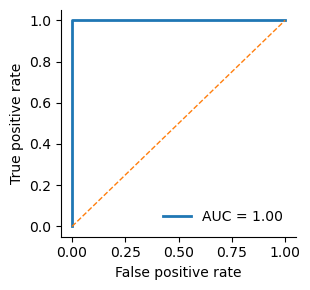

In [11]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# ===============================
# Fit model on training dataset
# ===============================
LR_L1.fit(X_total, y_total)

# ===============================
# Predicted probabilities
# ===============================
y_score = LR_L1.predict_proba(X_val)[:, 1]

# ===============================
# ROC computation
# ===============================
fpr, tpr, thresholds = roc_curve(y_val, y_score)
roc_auc = auc(fpr, tpr)

# ===============================
# Plot (same style as CV)
# ===============================
plt.figure(figsize=(3.2, 3.0))

plt.plot(
    fpr,
    tpr,
    lw=2,
    label=f"AUC = {roc_auc:.2f}"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    lw=1
)

plt.xlabel("False positive rate")
plt.ylabel("True positive rate")

plt.legend(loc="lower right", frameon=False)

# Clean journal style
ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()

# ===============================
# Save
# ===============================
comparison = Class_A + "_" + Class_B

#plt.savefig(f"C:/Users/tamer/Documents/PhD/ML/AUC/AUC_external_{comparison}.pdf",format="pdf",bbox_inches="tight")

plt.show()

In [12]:
stop

NameError: name 'stop' is not defined

## BoLASSO coefficients

In [ ]:
model = LR_L1

y_arr = np.asarray(y_total)  # <- important fix

n_boot = 1000
n_features = X_total.shape[1]
coef_mat = np.zeros((n_boot, n_features))

for b in range(n_boot):

    idx_R = np.where(y_arr == 0)[0]
    idx_S = np.where(y_arr == 1)[0]

    boot_R = np.random.choice(idx_R, size=len(idx_R), replace=True)
    boot_S = np.random.choice(idx_S, size=len(idx_S), replace=True)

    boot_idx = np.concatenate([boot_R, boot_S])

    Xb = X_total.iloc[boot_idx]
    yb = y_arr[boot_idx]  # <- now positional, no KeyError

    model.fit(Xb, yb)

    coefs = model.named_steps["logisticregression"].coef_[0]
    #support = model.named_steps['pipeline'].named_steps['selectkbest'].get_support()
    support = model.named_steps['pipeline'].named_steps['variancethreshold'].get_support()

    full_coef = np.zeros(n_features)
    full_coef[support] = coefs

    coef_mat[b, :] = full_coef

In [ ]:
print(coef_mat.shape)
print("Any non-zero coefficients?", np.any(coef_mat != 0))
print("Mean #nonzero per bootstrap:", np.mean(np.sum(coef_mat != 0, axis=1)))
print("Std  #nonzero per bootstrap:", np.std(np.sum(coef_mat != 0, axis=1)))

In [ ]:
coef_df = pd.DataFrame(coef_mat, columns=X_total.columns)

summary = pd.DataFrame({
    "metabolite": X_total.columns,
    "mean_coef": coef_df.mean(axis=0),
    "std_coef": coef_df.std(axis=0),
    # fraction of bootstraps where coefficient != 0 (usually equals "passed variance filter")
    "nonzero_freq": (coef_df != 0).mean(axis=0),
    # fraction of bootstraps where coefficient is positive / negative (ignoring zeros)
    "pos_freq": (coef_df > 0).mean(axis=0),
    "neg_freq": (coef_df < 0).mean(axis=0),
})

# sign consistency (close to 1 means always same sign; close to 0 means flips)
summary["sign_consistency"] = (summary["pos_freq"] - summary["neg_freq"]).abs()

# optional: "signal-to-noise" style ranking
summary["abs_mean_over_sd"] = summary["mean_coef"].abs() / (summary["std_coef"] + 1e-12)

# sort: first by stability, then by magnitude/stability ratio
summary = summary.sort_values(
    ["nonzero_freq", "sign_consistency", "abs_mean_over_sd"],
    ascending=[False, False, False]
).reset_index(drop=True)

print(summary.head(20))

In [ ]:
summary.to_excel("C:/Users/tamer/Documents/PhD/ML/ML_coefs/bootstrap.xlsx", index=False)
print("Saved: bootstrap_LR_L1_coeff_stability.xlsx")